<a href="https://colab.research.google.com/github/Kolo-Naukowe-Axion/QC1/blob/main/models/model_simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Environment Setup

This section handles dependency installation and imports. For reproducibility, all package versions should be pinned in a production environment.

### 1.1 Package Installation (Optional)

Set `INSTALL_DEPS = True` if running in a fresh environment. For production use, pin specific versions.

In [8]:
# Optional: Install dependencies if not already present
INSTALL_DEPS = False

if INSTALL_DEPS:
    import sys
    import subprocess

    packages = [
        'numpy',
        'scikit-learn',
        'ucimlrepo',
        'qiskit',
        'qiskit_algorithms',
        'qiskit-machine-learning',
        'iqm-client[qiskit]',
        'torch',
        'matplotlib'
    ]

    for pkg in packages:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

### 1.2 Imports

In [9]:
# Standard library
import random

# Third-party: Scientific computing
import numpy as np
import matplotlib.pyplot as plt

# Third-party: Machine learning
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Third-party: Quantum computing
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.gradients import ParamShiftEstimatorGradient

## 2. Reproducibility and Random Seed Control

In [10]:
def set_random_seed(seed: int = 42) -> None:
    """
    Set random seeds for reproducibility across numpy, PyTorch, and Python's random module.

    Parameters
    ----------
    seed : int
        Random seed value (default: 42)
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# Set global seed
RANDOM_SEED = 42
set_random_seed(RANDOM_SEED)

## 3. Data Preparation

Iris classification dataset: 150 samples, 4 features (sepal/petal length & width), 3 classes.

Each feature is angle-encoded on its own qubit (4 qubits total), scaled to $[-\pi/4, \pi/4]$.
Class labels $\{0, 1, 2\}$ are mapped to $\{-1.0, 0.0, +1.0\}$ to match the Pauli-Z
expectation value output range of the VQC.


In [11]:
import csv
from pathlib import Path

IRIS_SPECIES_TO_LABEL = {
    "Iris-setosa": 0,
    "Iris-versicolor": 1,
    "Iris-virginica": 2,
}
IRIS_FEATURE_COLUMNS = [
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm",
]

def _find_iris_csv() -> Path:
    for candidate in (Path("Iris.csv"), Path("../Iris.csv")):
        if candidate.is_file():
            return candidate
    raise FileNotFoundError(
        "Iris.csv not found. Run from the repo root or from models/."
    )

def prepare_data(test_size: float = 0.2, random_state: int = 42):
    """
    Load and preprocess the Iris dataset from Iris.csv.
    
    Returns scaled features (n, 4) and class labels {0, 1, 2}.
    Classes will be mapped to {-1.0, 0.0, 1.0} for training.
    """
    csv_path = _find_iris_csv()
    with csv_path.open(newline="") as f:
        rows = list(csv.DictReader(f))
    
    X = np.array(
        [[float(row[col]) for col in IRIS_FEATURE_COLUMNS] for row in rows],
        dtype=np.float64,
    )
    y_raw = np.array(
        [IRIS_SPECIES_TO_LABEL[row["Species"]] for row in rows],
        dtype=np.int64,
    )
    
    assert X.shape[1] == 4, f"Expected 4 features, got {X.shape[1]}"
    assert set(np.unique(y_raw)) == {0, 1, 2}, (
        f"Expected labels {{0, 1, 2}}, got {set(np.unique(y_raw))}"
    )
    
    X_train, X_test, y_train_raw, y_test_raw = train_test_split(
        X, y_raw, test_size=test_size, random_state=random_state, stratify=y_raw
    )
    
    scaler = MinMaxScaler(feature_range=(-np.pi / 4, np.pi / 4))
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print(f'Dataset loaded: {len(X_train_scaled)} train, {len(X_test_scaled)} test samples')
    print(f'Feature dimension: {X_train_scaled.shape[1]}')
    print(f'Class distribution (train): {np.bincount(y_train_raw)}')
    
    return X_train_scaled, X_test_scaled, y_train_raw, y_test_raw

## 4. Quantum Circuit Architecture

The quantum model consists of two components:
1. **Feature map** (angle encoding): Encodes classical data into quantum states
2. **Ansatz** (trainable circuit): Parametrized quantum circuit with learnable weights

### 4.1 Parametrized Ansatz

Ansatz with alternating rotation and entanglement layers. The circuit uses a ring topology for entanglement, alternating between forward (CRX) and reverse (CRY) connections.

In [12]:
def ansatz(n_qubits, depth):
    """
    Construct a hardware-efficient ansatz with alternating rotation and entanglement layers.

    Architecture
    ------------
    The ansatz consists of (depth // 2) macro-layers, where each macro-layer contains:
    - **Layer 1**: RY rotations + CRX entanglement (forward ring: i → i+1)
    - **Layer 2**: RX rotations + CRY entanglement (reverse ring: i → i-1)

    Parameters
    ----------
    n_qubits : int
        Number of qubits in the circuit
    depth : int
        Number of layers (must be even). Total macro-layers = depth // 2

    Returns
    -------
    QuantumCircuit
        Parametrized quantum circuit with learnable parameters θ

    Notes
    -----
    - Total trainable parameters: 2 × n_qubits × depth
    - Each macro-layer has 4 × n_qubits parameters:
        * n_qubits for RY rotations
        * n_qubits for CRX entanglement angles
        * n_qubits for RX rotations
        * n_qubits for CRY entanglement angles
    - Ring topology ensures all-to-all connectivity with minimal gate depth
    - Constraint: depth must be even (enforced by loop structure)
    """

    # Create a vector of learnable parameters.
    # Total parameters = 2 * num_qubits * depth (2 * n_qubits per full loop iteration).
    theta = ParameterVector('θ', 2 * n_qubits * depth)
    qc = QuantumCircuit(n_qubits)

    param_idx = 0

    # The loop iterates (depth // 2) times.
    for j in range(depth // 2):

        # -------- Layer 1 --------

        # Sub-layer: Independent RY rotations
        for i in range(n_qubits):
            qc.ry(theta[param_idx], i)
            param_idx += 1

        # Sub-layer: Entanglement (CRX) - Ring Topology
        # Connects i -> i+1 (wrapping around to 0 at the end)
        for i in range(n_qubits):
            control = i
            target = (i + 1) % n_qubits
            qc.crx(theta[param_idx], control, target)
            param_idx += 1


        # -------- Layer 2 --------

        # Sub-layer: Independent RX rotations
        for i in range(n_qubits):
            qc.rx(theta[param_idx], i)
            param_idx += 1

        # Sub-layer: Entanglement (CRY) - Reverse Ring Topology
        # Connects i -> i-1 (wrapping around to N-1)
        for i in range(n_qubits):
            control = i
            target = (i - 1) % n_qubits
            qc.cry(theta[param_idx], control, target)
            param_idx += 1

    return qc

### 4.2 Hybrid Variational Quantum Circuit

The `HybridModel` class implements a VQC by integrating the quantum circuit with PyTorch's autograd system via Qiskit's `TorchConnector`. This enables gradient-based optimization of quantum parameters using classical optimizers.

In [13]:
class HybridModel(nn.Module):
    """
    Hybrid Variational Quantum Circuit (VQC) for binary classification.

    The model combines:
    1. Angle encoding feature map (classical data → quantum state)
    2. Parametrized ansatz (trainable quantum circuit)
    3. Observable measurement (quantum state → classical expectation value)
    4. PyTorch integration via TorchConnector (enables backpropagation)

    Parameters
    ----------
    ansatz_circuit : QuantumCircuit
        Parametrized quantum circuit with trainable weights
    num_qubits : int
        Number of qubits (must match feature dimension)

    Attributes
    ----------
    qnn : EstimatorQNN
        Qiskit's EstimatorQNN that computes expectation values
    quantum_layer : TorchConnector
        PyTorch-compatible wrapper enabling gradient computation

    Notes
    -----
    - **Feature encoding**: RY(x_i) on qubit i encodes feature x_i
    - **Observable**: Pauli-Z on qubit 0, measuring spin in computational basis
    - **Output range**: [-1, +1] (expectation value of Z operator)
    - **Gradient method**: Parameter shift rule for quantum gradients
    - **Simulator**: StatevectorEstimator (change for real quantum hardware)
    """

    def __init__(self, ansatz_circuit, num_qubits):
        super().__init__()

        # Create angle encoding feature map
        self.feature_map = self._create_angle_encoding(num_qubits)

        # Compose full quantum circuit: feature_map → ansatz
        self.qc = QuantumCircuit(num_qubits)
        self.qc.compose(self.feature_map, qubits=range(num_qubits), inplace=True)
        self.qc.compose(ansatz_circuit, inplace=True)

        # Separate input parameters (from feature map) and weight parameters (from ansatz)
        # This distinction is crucial for EstimatorQNN to correctly handle data vs. trainable weights
        input_params = list(self.feature_map.parameters)
        weight_params = list(ansatz_circuit.parameters)

        # Define observable: measure Z on qubit 0 (identity on other qubits)
        # Pauli string ordering: rightmost character = qubit 0
        # Example for 5 qubits: "IIIIZ" measures Z on q0, I on q1-q4
        observable = SparsePauliOp.from_list([("I" * (num_qubits - 1) + "Z", 1)])

        # Initialize statevector simulator for noiseless quantum simulation
        # NOTE: Replace with Sampler or real backend for quantum hardware deployment
        estimator = StatevectorEstimator()

        # Parameter-shift gradients (ReverseEstimatorGradient breaks on Qiskit 2.4+ with this ansatz)
        # This is exact (not finite-difference) and works on hardware
        gradient = ParamShiftEstimatorGradient(estimator)

        # Create variational quantum circuit using EstimatorQNN
        # EstimatorQNN computes <ψ|O|ψ> where |ψ> = ansatz(weights)|feature_map(x)>
        self.qnn = EstimatorQNN(
            circuit=self.qc,
            observables=observable,
            input_params=input_params,
            weight_params=weight_params,
            estimator=estimator,
            gradient=gradient
        )

        # Wrap the VQC as a PyTorch module
        # TorchConnector bridges Qiskit and PyTorch autograd systems,
        # allowing standard PyTorch optimizers (SGD, Adam, etc.) to train quantum parameters
        self.quantum_layer = TorchConnector(self.qnn)

    def _create_angle_encoding(self, num_qubits: int) -> QuantumCircuit:
        """
        Create angle encoding feature map: |0⟩ → RY(x₀) ⊗ RY(x₁) ⊗ ... ⊗ RY(xₙ) |0⟩

        Each classical feature x_i ∈ [0, π] is encoded as a rotation angle on qubit i.
        This maps the feature vector to the amplitude of the quantum state.

        Parameters
        ----------
        num_qubits : int
            Number of qubits (and features)

        Returns
        -------
        QuantumCircuit
            Feature map circuit with n_qubits input parameters
        """
        qc_data = QuantumCircuit(num_qubits)
        input_params = ParameterVector('x', num_qubits)
        for i in range(num_qubits):
            qc_data.ry(input_params[i], i)
        return qc_data

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through the hybrid variational quantum circuit.

        Parameters
        ----------
        x : torch.Tensor
            Input features, shape (batch_size, num_qubits)

        Returns
        -------
        torch.Tensor
            Expectation values, shape (batch_size, 1), range [-1, +1]
        """
        return self.quantum_layer(x)

## 5. Hyperparameters & Data Tensors


In [14]:
EPOCHS = 30
BATCH_SIZE = 16
LEARNING_RATE = 0.01
NUM_QUBITS = 4  # one feature per qubit (4 Iris features)
ANSATZ_DEPTH = 6
IRIS_TARGET_NAMES = ["Setosa", "Versicolor", "Virginica"]
CLASS_TARGETS = np.array([-1.0, 0.0, 1.0], dtype=np.float32)

# Load and prepare data
X_train, X_test, y_train_raw, y_test_raw = prepare_data(
    test_size=0.2,
    random_state=RANDOM_SEED,
)

# Map class labels {0, 1, 2} -> {-1.0, 0.0, 1.0}
y_train = (y_train_raw - 1).astype(np.float32)
y_test  = (y_test_raw  - 1).astype(np.float32)

X_train = X_train.astype(np.float32)
X_test  = X_test.astype(np.float32)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_test_tensor  = torch.tensor(X_test,  dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test,  dtype=torch.float32).reshape(-1, 1)

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor), batch_size=BATCH_SIZE, shuffle=True
)


Dataset loaded: 120 train, 30 test samples
Feature dimension: 4
Class distribution (train): [40 40 40]


## 6. Model Training


In [15]:
def score_to_class(scores: np.ndarray, class_targets: np.ndarray) -> np.ndarray:
    """Map continuous VQC output to the nearest class index {0, 1, 2}."""
    scores = np.asarray(scores).reshape(-1, 1)
    return np.abs(scores - class_targets.reshape(1, -1)).argmin(axis=1)


def train_epoch(model, train_loader, optimizer, loss_fn):
    model.train()
    epoch_loss = 0.0
    num_batches = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = loss_fn(output, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        num_batches += 1
    return epoch_loss / num_batches


def evaluate(model, X_tensor, y_tensor, loss_fn, class_targets):
    model.eval()
    with torch.no_grad():
        outputs = model(X_tensor)
        loss = loss_fn(outputs, y_tensor).item()
        pred_classes = score_to_class(outputs.cpu().numpy(), class_targets)
        true_classes = score_to_class(y_tensor.cpu().numpy(), class_targets)
        accuracy = (pred_classes == true_classes).mean()
    return {'loss': loss, 'accuracy': accuracy}


In [16]:
final_ansatz = ansatz(NUM_QUBITS, ANSATZ_DEPTH)
model = HybridModel(final_ansatz, NUM_QUBITS)
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_loss_history = []
test_loss_history = []
test_accuracy_history = []

print(f'Starting training for {EPOCHS} epochs...')
print(f'Model: {NUM_QUBITS} qubits, ansatz depth {ANSATZ_DEPTH}')
print(f'Task: Iris classification ({3} classes mapped to {-1, 0, 1})')
print(
    f'Trainable parameters: '
    f"{sum(p.numel() for p in model.parameters() if p.requires_grad)}"
)
print('-' * 60)

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, loss_function)
    test_metrics = evaluate(model, X_test_tensor, y_test_tensor, loss_function, CLASS_TARGETS)

    train_loss_history.append(train_loss)
    test_loss_history.append(test_metrics['loss'])
    test_accuracy_history.append(test_metrics['accuracy'])

    print(
        f'Epoch {epoch + 1:3d}/{EPOCHS} | '
        f'Train Loss: {train_loss:.4f} | '
        f'Test Loss: {test_metrics["loss"]:.4f} | '
        f'Test Acc: {test_metrics["accuracy"]:.4f}'
    )

print('-' * 60)
print('Training complete.')

Starting training for 30 epochs...
Model: 4 qubits, ansatz depth 6
Task: Iris classification (3 classes mapped to (-1, 0, 1))
Trainable parameters: 48
------------------------------------------------------------
Epoch   1/30 | Train Loss: 1.1460 | Test Loss: 1.0378 | Test Acc: 0.3333
Epoch   2/30 | Train Loss: 0.9906 | Test Loss: 0.8647 | Test Acc: 0.3333
Epoch   3/30 | Train Loss: 0.8101 | Test Loss: 0.6935 | Test Acc: 0.3333
Epoch   4/30 | Train Loss: 0.6499 | Test Loss: 0.5663 | Test Acc: 0.3333
Epoch   5/30 | Train Loss: 0.5165 | Test Loss: 0.4620 | Test Acc: 0.3333
Epoch   6/30 | Train Loss: 0.4153 | Test Loss: 0.3742 | Test Acc: 0.3333
Epoch   7/30 | Train Loss: 0.3348 | Test Loss: 0.2966 | Test Acc: 0.3667
Epoch   8/30 | Train Loss: 0.2750 | Test Loss: 0.2469 | Test Acc: 0.4667
Epoch   9/30 | Train Loss: 0.2132 | Test Loss: 0.2100 | Test Acc: 0.6667
Epoch  10/30 | Train Loss: 0.1819 | Test Loss: 0.1898 | Test Acc: 0.8000
Epoch  11/30 | Train Loss: 0.1673 | Test Loss: 0.1669 | Te

Final Test Accuracy: 0.8667
Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.75      0.90      0.82        10
   Virginica       0.88      0.70      0.78        10

    accuracy                           0.87        30
   macro avg       0.88      0.87      0.87        30
weighted avg       0.88      0.87      0.87        30

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  3  7]]


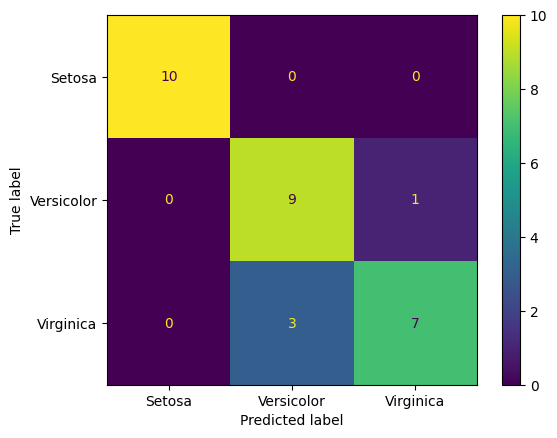

In [17]:
with torch.no_grad():
    test_outputs = model(X_test_tensor).cpu().numpy()

y_pred = score_to_class(test_outputs, CLASS_TARGETS)
y_true = score_to_class(y_test_tensor.cpu().numpy(), CLASS_TARGETS)

accuracy = accuracy_score(y_true, y_pred)
print(f"Final Test Accuracy: {accuracy:.4f}")
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=IRIS_TARGET_NAMES))

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(cm, display_labels=IRIS_TARGET_NAMES).plot()

## 7. Visualisation


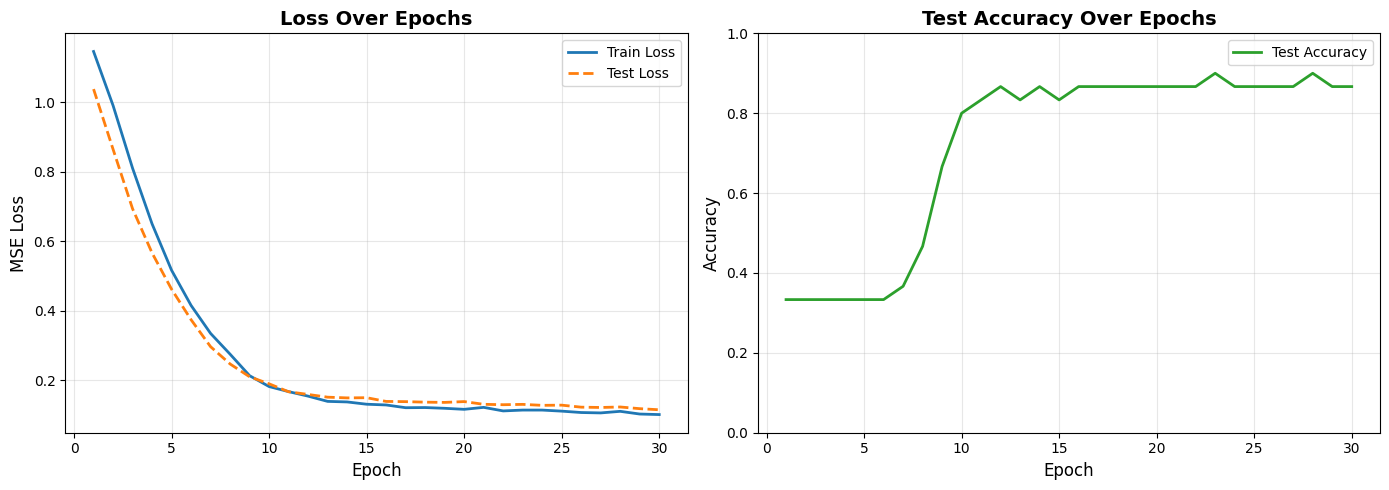

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(train_loss_history) + 1)

# --- Plot 1: Loss curves ---
axes[0].plot(epochs_range, train_loss_history, label='Train Loss', color='#1f77b4', linewidth=2)
axes[0].plot(
    epochs_range,
    test_loss_history,
    label='Test Loss',
    color='#ff7f0e',
    linewidth=2,
    linestyle='--',
)
axes[0].set_title('Loss Over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('MSE Loss', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Accuracy curve ---
axes[1].plot(epochs_range, test_accuracy_history, label='Test Accuracy', color='#2ca02c', linewidth=2)
axes[1].set_title('Test Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Summary and Reproducibility Notes

### Reproducibility

- **Random seed**: Fixed at `RANDOM_SEED = 42`
- **Train/test split**: Stratified 80/20 split
- **Feature scaling**: MinMaxScaler fit only on training data

### VQC Architecture Summary

- **Task**: Multiclass classification — Iris dataset (3 classes)
- **Qubits**: 4 (one per feature: sepal length, sepal width, petal length, petal width)
- **Ansatz depth**: 6 layers (3 macro-layers)
- **Trainable parameters**: 192 quantum parameters (2 × 4 × 6 × 4)
- **Feature encoding**: Angle encoding via RY gates, scaled to $[-\pi/4, \pi/4]$
- **Observable**: Pauli-Z expectation on qubit 0 (output range $[-1, +1]$)
- **Class mapping**: Setosa → $-1.0$, Versicolor → $0.0$, Virginica → $+1.0$
- **Optimizer**: Adam, learning rate 0.01
- **Loss**: Mean Squared Error (MSE)

### References

- Qiskit Machine Learning: https://qiskit.org/ecosystem/machine-learning/
- Variational Quantum Algorithms: Cerezo et al., Nature Reviews Physics 3, 625–644 (2021)
